In [ ]:
# Import packages
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [ ]:
# Q1.
heart = pd.read_csv("framingham.csv")

print(f"{heart.shape}\n")
print(f"{heart.columns}\n")

print(f"{heart['TenYearCHD'].value_counts()}\n")
print(heart['TenYearCHD'].value_counts(normalize=True))

(4159, 16)

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

TenYearCHD
0    3526
1     633
Name: count, dtype: int64

TenYearCHD
0    0.8478
1    0.1522
Name: proportion, dtype: float64


In [ ]:
# Q2.
cols = ["totChol", "diabetes", "cigsPerDay", "age", "TenYearCHD"]

missing_counts = heart[cols].isna().sum()
missing_percent = heart[cols].isna().mean() * 100

print(f"{missing_counts}\n")
print(f"{missing_percent}")

totChol       0
diabetes      0
cigsPerDay    0
age           0
TenYearCHD    0
dtype: int64

totChol       0.0
diabetes      0.0
cigsPerDay    0.0
age           0.0
TenYearCHD    0.0
dtype: float64


In [ ]:
# Q3.
vars_lr = ["TenYearCHD", "totChol", "diabetes", "cigsPerDay", "age"]
heart_lr = heart[vars_lr]

# (a) Drop NA
heart_lr_drop = heart_lr.dropna()

# (b) Impute
heart_lr_imp = heart_lr.copy()

for col in heart_lr_imp.columns:
    if heart_lr_imp[col].dtype in ['float64', 'int64']:
        heart_lr_imp[col].fillna(heart_lr_imp[col].median(), inplace=True)
    else:
        heart_lr_imp[col].fillna(heart_lr_imp[col].mode()[0], inplace=True)

In [ ]:
# Q4.
print(len(heart_lr_drop))
print(len(heart_lr_imp))

4159
4159


In [ ]:
# Q5.
X = heart_lr_imp.drop("TenYearCHD", axis=1)
y = heart_lr_imp["TenYearCHD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=88, stratify=y
)

In [ ]:
# Q6
print(f"{y_train.value_counts(normalize=True)}\n")
print(y_test.value_counts(normalize=True))

TenYearCHD
0    0.847708
1    0.152292
Name: proportion, dtype: float64

TenYearCHD
0    0.848077
1    0.151923
Name: proportion, dtype: float64


In [ ]:
# Q7
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# Q8
odds_ratios = np.exp(model.coef_[0])
print(pd.DataFrame({
    "Feature": X.columns,
    "Odds Ratio": odds_ratios
}))

      Feature  Odds Ratio
0     totChol    1.002616
1    diabetes    2.438338
2  cigsPerDay    1.026549
3         age    1.088254


In [ ]:
# Q9
probs = model.predict_proba(X_test)[:,1]
print(pd.Series(probs).describe())

count    1040.000000
mean        0.151895
std         0.097339
min         0.022081
25%         0.075587
50%         0.128029
75%         0.208401
max         0.587827
dtype: float64


In [ ]:
# Q10
pred_05 = (probs >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred_05)
print(f"Confusion Matrix:\n{cm}\n")
print(f"Classification Report:\n{classification_report(y_test, pred_05)}")

Confusion Matrix:
[[880   2]
 [154   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       882
           1       0.67      0.03      0.05       158

    accuracy                           0.85      1040
   macro avg       0.76      0.51      0.48      1040
weighted avg       0.82      0.85      0.79      1040



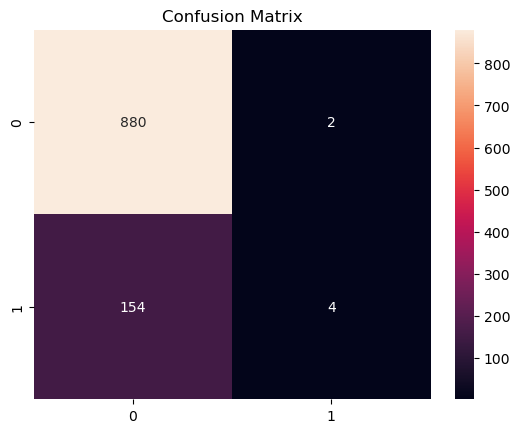

In [ ]:
# Q11
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Q12.
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = []

for t in np.arange(0.10, 0.91, 0.05):
    pred = (probs >= t).astype(int)

    results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

df_thresh = pd.DataFrame(results)
print(f"{df_thresh}\n")

best = df_thresh.loc[df_thresh['f1'].idxmax()]
print(f"{best}")

    threshold  accuracy  precision    recall        f1
0        0.10  0.467308   0.196319  0.810127  0.316049
1        0.15  0.623077   0.234091  0.651899  0.344482
2        0.20  0.725000   0.276224  0.500000  0.355856
3        0.25  0.785577   0.305389  0.322785  0.313846
4        0.30  0.823077   0.345238  0.183544  0.239669
5        0.35  0.841346   0.418605  0.113924  0.179104
6        0.40  0.843269   0.391304  0.056962  0.099448
7        0.45  0.847115   0.461538  0.037975  0.070175
8        0.50  0.850000   0.666667  0.025316  0.048780
9        0.55  0.849038   1.000000  0.006329  0.012579
10       0.60  0.848077   0.000000  0.000000  0.000000
11       0.65  0.848077   0.000000  0.000000  0.000000
12       0.70  0.848077   0.000000  0.000000  0.000000
13       0.75  0.848077   0.000000  0.000000  0.000000
14       0.80  0.848077   0.000000  0.000000  0.000000
15       0.85  0.848077   0.000000  0.000000  0.000000
16       0.90  0.848077   0.000000  0.000000  0.000000

threshold

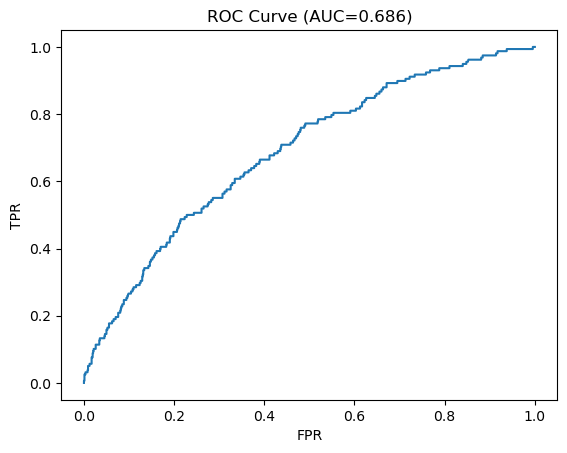

In [ ]:
# Q13.
fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC={auc:.3f})")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [ ]:
# Q14.
df_cal = pd.DataFrame({"prob": probs, "actual": y_test})

df_cal["bin"] = pd.qcut(df_cal["prob"], 10, duplicates='drop')

calibration = df_cal.groupby("bin").agg(
    mean_prob=("prob","mean"),
    actual_rate=("actual","mean")
)

print(calibration)

                  mean_prob  actual_rate
bin                                     
(0.0211, 0.0492]   0.039461     0.038462
(0.0492, 0.0656]   0.057901     0.067308
(0.0656, 0.0839]   0.075244     0.076923
(0.0839, 0.105]    0.094548     0.115385
(0.105, 0.128]     0.115337     0.134615
(0.128, 0.154]     0.142516     0.134615
(0.154, 0.187]     0.170468     0.163462
(0.187, 0.228]     0.209204     0.192308
(0.228, 0.285]     0.256090     0.278846
(0.285, 0.588]     0.358186     0.317308


In [ ]:
# Q15.
X_train_int = X_train.copy()
X_train_int["age_cigs"] = X_train["age"] * X_train["cigsPerDay"]

model_int = LogisticRegression(max_iter=1000)
model_int.fit(X_train_int, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# Q16.
heart_dt = heart_lr_imp.copy()
heart_dt["TenYearCHD"] = heart_dt["TenYearCHD"].astype(int)

In [ ]:
# Q17.
X_dt = heart_dt.drop("TenYearCHD", axis=1)
y_dt = heart_dt["TenYearCHD"]

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.25, random_state=88, stratify=y_dt
)

In [ ]:
# Q18.
tree0 = DecisionTreeClassifier(random_state=88)
tree0.fit(X_train_dt, y_train_dt)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,88
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


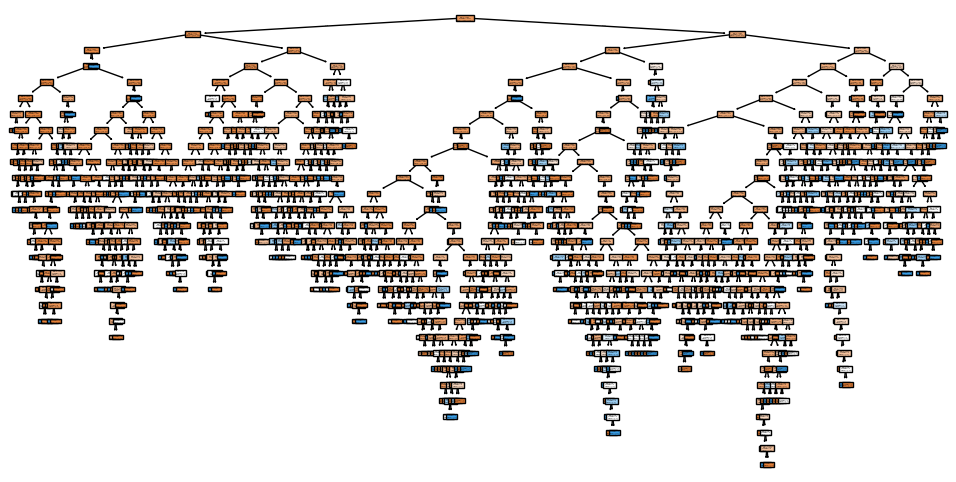

In [ ]:
# Q19.
plt.figure(figsize=(12,6))
plot_tree(tree0, feature_names=X_dt.columns, filled=True)
plt.show()

In [ ]:
# Q20.
tree_big = DecisionTreeClassifier(
    random_state=88,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)
tree_big.fit(X_train_dt, y_train_dt)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,88
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
path = tree_big.cost_complexity_pruning_path(X_train_dt, y_train_dt)
ccp_alphas = path.ccp_alphas

trees = []
for ccp in ccp_alphas:
    t = DecisionTreeClassifier(random_state=88, ccp_alpha=ccp)
    t.fit(X_train_dt, y_train_dt)
    trees.append(t)

# choose best based on accuracy
best_tree = max(trees, key=lambda t: t.score(X_test_dt, y_test_dt))

In [ ]:
# Q21.
pred_tree = best_tree.predict(X_test_dt)
prob_tree = best_tree.predict_proba(X_test_dt)[:,1]

In [ ]:
# Q22.
cm_tree = confusion_matrix(y_test_dt, pred_tree)
print(cm_tree)

[[882   0]
 [158   0]]


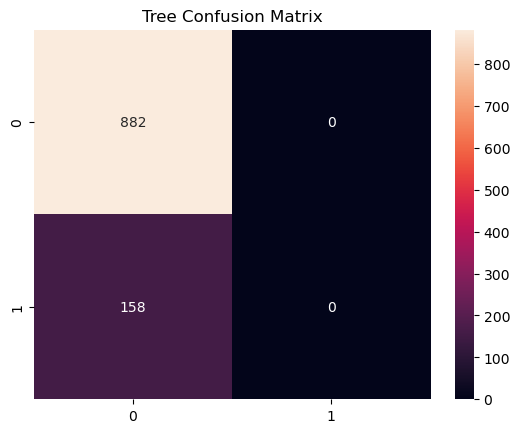

In [ ]:
# Q23.
sns.heatmap(cm_tree, annot=True, fmt='d')
plt.title("Tree Confusion Matrix")
plt.show()

In [ ]:
# Q24.
results_tree = []

for t in np.arange(0.10, 0.91, 0.05):
    pred = (prob_tree >= t).astype(int)

    results_tree.append({
        "threshold": t,
        "f1": f1_score(y_test_dt, pred)
    })

df_tree_thresh = pd.DataFrame(results_tree)
print(df_tree_thresh)

    threshold        f1
0        0.10  0.297076
1        0.15  0.321321
2        0.20  0.304910
3        0.25  0.304910
4        0.30  0.023952
5        0.35  0.023952
6        0.40  0.023952
7        0.45  0.023952
8        0.50  0.000000
9        0.55  0.000000
10       0.60  0.000000
11       0.65  0.000000
12       0.70  0.000000
13       0.75  0.000000
14       0.80  0.000000
15       0.85  0.000000
16       0.90  0.000000


In [ ]:
# Q25.
auc_tree = roc_auc_score(y_test_dt, prob_tree)
print("Tree AUC:", auc_tree)

Tree AUC: 0.6342353397055023


In [ ]:
# Q26.
print("Logistic AUC:", auc)
print("Tree AUC:", auc_tree)

Logistic AUC: 0.6857975257613594
Tree AUC: 0.6342353397055023


In [ ]:
# Q27.
importances = pd.Series(best_tree.feature_importances_, index=X_dt.columns)
print(importances.sort_values(ascending=False))

age           0.829685
cigsPerDay    0.094053
diabetes      0.076262
totChol       0.000000
dtype: float64


In [ ]:
# Q28.
depth_results = []

for d in range(1,7):
    t = DecisionTreeClassifier(max_depth=d, random_state=88)
    t.fit(X_train_dt, y_train_dt)

    acc = t.score(X_test_dt, y_test_dt)
    depth_results.append((d, acc))

print(pd.DataFrame(depth_results, columns=["depth","accuracy"]))

   depth  accuracy
0      1  0.848077
1      2  0.848077
2      3  0.846154
3      4  0.840385
4      5  0.838462
5      6  0.836538


In [ ]:
# Q29.
scores = [(ccp, t.score(X_test_dt, y_test_dt)) for ccp, t in zip(ccp_alphas, trees)]
df_cp = pd.DataFrame(scores, columns=["ccp","score"])

best_score = df_cp["score"].max()
threshold = best_score - df_cp["score"].std()

selected = df_cp[df_cp["score"] >= threshold].iloc[0]
print(selected)

ccp      0.000412
score    0.817308
Name: 11, dtype: float64


In [ ]:
# Q30.
# (a) The tree mostly learned that age matters the most. Older people have higher risk. Smoking and diabetes also affect the risk a little.
# (b) Overfitting means the tree becomes too complex and makes too many splits. It fits the training data very well but does not work well on new data.
# (c) I would add features like blood pressure, BMI, and cholesterol. These are important for heart health and can make the model better.
